In [283]:
import numpy as np
import random as rm
import matplotlib.pyplot as plt

betta=1
gamma=1/5
I0=0.1
P_s=0.1
P_b=0.1
dim=1000
ND=100
L=dim

adj={1:(0,1),2:(1,0),3:(0,-1),4:(0,-1)}

snod=[]
inod=[]
rnod=[]

In [284]:
def initial_condition():
    nodes=np.ndarray((dim,dim,2),dtype=bool)
    edges=np.ndarray((2*dim,dim),dtype=bool)
    for i in range(dim):
        for j in range(dim):
            nodes[i][j][0]=False
            nodes[i][j][1]=False
    for i in range(2*dim):
        for j in range(dim):
            edges[i][j]=False

    n_i=0
    while n_i < I0*(dim**2):
        rmix=rm.randint(0,dim-1)
        rmiy=rm.randint(0,dim-1)
        if nodes[rmix,rmiy,0]==False and nodes[rmix,rmiy,1]==False :
            nodes[rmix,rmiy,0]=True
            n_i+=1

    n_s=0
    while n_s < P_s*(dim**2):
        rmsx=rm.randint(0,dim-1)
        rmsy=rm.randint(0,dim-1)
        if nodes[rmsx,rmsy,0]==False and nodes[rmsx,rmsy,1]==False :
            nodes[rmsx,rmsy,1]=True
            n_s+=1
    n_b=0
    while n_b < P_b*(2* dim**2):
        rmbx=rm.randint(0,(2*dim)-1)
        rmby=rm.randint(0,dim-1)
        if edges[rmbx,rmby]==False :
            edges[rmbx,rmby]=True
            n_b+=1
    return (nodes,edges)

In [285]:
def pps(n,ND) :
    P=n*100/ND
    PP= "{:.2f}".format(P)
    print("\r",end="")
    print("processes",PP,"% completed:   ",end="")
    i=50*n/ND
    a=50-int(i)
    b=(int(i)+1)*"🟩"
    c=(a-1)*"⬜️"
    print(b,end="")
    print(c, end="")

In [286]:
def simulation():
    nd_p=0
    while nd_p<=ND:

        pps(nd_p,ND)
        
        snum=0
        inum=0
        rnum=0
        for i in range(dim):
            for j in range(dim):
                if nodes[i,j,0]==False and nodes[i,j,1]==False :
                    snum+=1
                if nodes[i,j,0]==True and nodes[i,j,1]==False :
                    inum+=1
                if nodes[i,j,0]==False and nodes[i,j,1]==True :
                    rnum+=1
                if nodes[i,j,0]==True and nodes[i,j,1]==True :
                    print("fuck bro there is sth not right here")
        snod.append(snum)
        inod.append(inum)
        rnod.append(rnum-(P_s*(dim**2)))

        n_L=0
        while n_L<L**2 :
            #indexing a random node
            rmx=rm.randint(-1,dim-2)
            rmy=rm.randint(-1,dim-2)
            #choose a random neighbor
            rmz=rm.randint(1,4)
            adjx=rmx+adj[rmz][0]
            adjy=rmy+adj[rmz][1]
            #dynamic loop for being seek
            if nodes[rmx,rmy,0]==True and nodes[adjx,adjy,0]==False and nodes[adjx,adjy,1]==False :
                if edges[rmx+adjx,min(rmy,adjy)]==False and rm.random()<betta:
                    nodes[adjx,adjy,0]=True
            #do the same for recovery
            rmx=rm.randint(0,dim-1)
            rmy=rm.randint(0,dim-1)
            if nodes[rmx,rmy,0]==True and rm.random()<gamma :
                nodes[rmx,rmy,0]=False
                nodes[rmx,rmy,1]=True
            n_L+=1
        nd_p+=1
    print("\r","computing successfully completed!   ",50*"🟦")

In [287]:
(nodes,edges)=initial_condition()
simulation()

 computing successfully completed!    🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦🟦


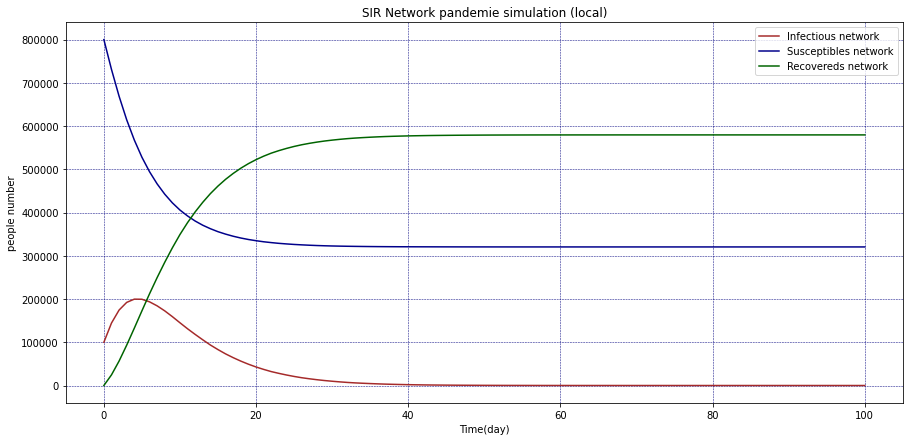

In [289]:
plt.figure(figsize=(15,7))
plt.rcParams.update({'font.size': 10})
plt.title('SIR Network pandemie simulation (local)')
plt.plot(inod,'brown', label='Infectious network')
plt.plot(snod, 'darkblue', label='Susceptibles network')
plt.plot(rnod, 'darkgreen', label='Recovereds network')
plt.legend(loc=0)
plt.xlabel('Time(day)')
plt.ylabel('people number')
plt.grid(color = 'navy', linestyle = '--', linewidth = 0.5)
plt.savefig('SIR-Network')
plt.show()